<a href="https://colab.research.google.com/github/kittiporntum1-cell/ADALL_github/blob/main/Project_ADALL_Kittiporn_Wongsuebsbantati.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step-by-Step Setup
Step 1: Install the OpenAI SDK library, and other dependencies

In [ ]:
!pip install openai pandas numpy matplotlib seaborn python-dotenv


Step 2: Set Your API Key

Step 3: Instantiate an OpenAI Client

In [ ]:
from google.colab import userdata
from openai import OpenAI

# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    api_key=api_key,
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from datetime import datetime
from openai import OpenAI

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the ADALL_Project_Dataset into Python.

In [ ]:
# another load dataset template (github)

github_raw_url = 'https://raw.githubusercontent.com/kittiporntum1-cell/ADALL_github/refs/heads/main/Fraud_Synthetic_ADLL%20project.csv'

df = pd.read_csv(github_raw_url)

print('Dataset loaded successfully.')
print('Shape:', df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (5000, 19)


,TransactionID,Transaction_DateTime,TransactionAmt,card4,card6,Customer_Email,Card_BIN,BIN_Risk_Level,Card_Last4,Customer_Status,Risk_Score,Rule_Triggered,Final_Outcome,Chargeback_Flag,Velocity_Attack_Flag,DeviceType,DeviceInfo,P_emaildomain,isFraud
0,3095550,2025-01-25 19:39:04,375.000,visa,credit,john.lim286@anonymous.com,459009,Medium,9077,New User,66,HIGH_AMOUNT,Rejected,No,No,desktop,Windows,anonymous.com,0
1,3549342,2025-06-22 13:10:50,106.000,mastercard,credit,tom.wong829@gmail.com,549793,Low,3104,New User,49,NaN,Approved,No,No,desktop,0,NaN,0
2,3105576,2025-01-27 19:25:26,20.988,visa,debit,tom.tan789@hotmail.com,458717,Low,4377,Existing User,45,NaN,Approved,No,No,desktop,0,hotmail.com,0
3,3005391,2025-01-06 17:41:30,100.000,visa,credit,mike.chan183@yahoo.com,428539,Low,2364,Existing User,20,NaN,Approved,No,No,desktop,Windows,yahoo.com,0
4,3018720,2025-01-10 00:25:30,37.079,mastercard,debit,amy.lee935@gmail.com,513796,Low,9462,New User,47,NaN,Approved,No,No,desktop,Windows,gmail.com,0


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/data/Fraud_Synthetic_ADLL project.csv")
df.head()

,TransactionID,Transaction_DateTime,TransactionAmt,card4,card6,Customer_Email,Card_BIN,BIN_Risk_Level,Card_Last4,Customer_Status,Risk_Score,Rule_Triggered,Final_Outcome,Chargeback_Flag,Velocity_Attack_Flag,DeviceType,DeviceInfo,P_emaildomain,isFraud
0,3095550,2025-01-25 19:39:04,375.000,visa,credit,john.lim286@anonymous.com,459009,Medium,9077,New User,66,HIGH_AMOUNT,Rejected,No,No,desktop,Windows,anonymous.com,0
1,3549342,2025-06-22 13:10:50,106.000,mastercard,credit,tom.wong829@gmail.com,549793,Low,3104,New User,49,NaN,Approved,No,No,desktop,0,NaN,0
2,3105576,2025-01-27 19:25:26,20.988,visa,debit,tom.tan789@hotmail.com,458717,Low,4377,Existing User,45,NaN,Approved,No,No,desktop,0,hotmail.com,0
3,3005391,2025-01-06 17:41:30,100.000,visa,credit,mike.chan183@yahoo.com,428539,Low,2364,Existing User,20,NaN,Approved,No,No,desktop,Windows,yahoo.com,0
4,3018720,2025-01-10 00:25:30,37.079,mastercard,debit,amy.lee935@gmail.com,513796,Low,9462,New User,47,NaN,Approved,No,No,desktop,Windows,gmail.com,0


I'll use pandas pd to read the dataset into a DataFrame df.

Helper Functions For Data Analysis

Let's create a function to summarize our dataset for the AI.

This function loops through each column in our dataset and creates a detailed summary including data type, missing values, and key statistics. This summary will help the AI understand our data better.

In [ ]:
df.info() #dataset structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionID         5000 non-null   int64  
 1   Transaction_DateTime  5000 non-null   object 
 2   TransactionAmt        5000 non-null   float64
 3   card4                 4996 non-null   object 
 4   card6                 4996 non-null   object 
 5   Customer_Email        5000 non-null   object 
 6   Card_BIN              5000 non-null   int64  
 7   BIN_Risk_Level        5000 non-null   object 
 8   Card_Last4            5000 non-null   int64  
 9   Customer_Status       5000 non-null   object 
 10  Risk_Score            5000 non-null   int64  
 11  Rule_Triggered        193 non-null    object 
 12  Final_Outcome         5000 non-null   object 
 13  Chargeback_Flag       5000 non-null   object 
 14  Velocity_Attack_Flag  5000 non-null   object 
 15  DeviceType           

In [ ]:
df.describe() #Dataset Statistics

,TransactionID,TransactionAmt,Card_BIN,Card_Last4,Risk_Score,isFraud
count,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,3.235033e+06,81.463617,475061.379600,5510.170000,38.45060,0.077000
std,1.768714e+05,94.084746,54266.292483,2580.217151,13.30599,0.266618
min,2.987004e+06,0.878000,370014.000000,1003.000000,15.00000,0.000000
25%,3.078718e+06,25.000000,432345.250000,3310.500000,28.00000,0.000000
50%,3.197488e+06,50.000000,470726.500000,5524.000000,37.00000,0.000000
75%,3.388900e+06,100.000000,521331.750000,7701.750000,46.00000,0.000000
max,3.577265e+06,1200.000000,659516.000000,9993.000000,97.00000,1.000000


Give data snapshot to AI for prompt

In [ ]:
# Convert the first 300 rows to a string to send to OpenAI
data_preview = df.head(300).to_csv(index=False)
print(data_preview)

TransactionID,Transaction_DateTime,TransactionAmt,card4,card6,Customer_Email,Card_BIN,BIN_Risk_Level,Card_Last4,Customer_Status,Risk_Score,Rule_Triggered,Final_Outcome,Chargeback_Flag,Velocity_Attack_Flag,DeviceType,DeviceInfo,P_emaildomain,isFraud
3095550,2025-01-25 19:39:04,375.0,visa,credit,john.lim286@anonymous.com,459009,Medium,9077,New User,66,HIGH_AMOUNT,Rejected,No,No,desktop,Windows,anonymous.com,0
3549342,2025-06-22 13:10:50,106.0,mastercard,credit,tom.wong829@gmail.com,549793,Low,3104,New User,49,,Approved,No,No,desktop,0,,0
3105576,2025-01-27 19:25:26,20.988,visa,debit,tom.tan789@hotmail.com,458717,Low,4377,Existing User,45,,Approved,No,No,desktop,0,hotmail.com,0
3005391,2025-01-06 17:41:30,100.0,visa,credit,mike.chan183@yahoo.com,428539,Low,2364,Existing User,20,,Approved,No,No,desktop,Windows,yahoo.com,0
3018720,2025-01-10 00:25:30,37.079,mastercard,debit,amy.lee935@gmail.com,513796,Low,9462,New User,47,,Approved,No,No,desktop,Windows,gmail.com,0
3109545,2025-01-28 20:33:

Section 1 — Business Understanding

In [ ]:
# Business insight

prompt = """
You are an experienced Data Scientist and Fraud Analytics Consultant.

Context:

I am a Fraud Prevention Specialist at EBANX.

My daily work involves reviewing merchant transaction activity, fraud patterns, approval rates, chargeback rates
and fraud rule performance.

My goal is to maximize approval rates while minimizing chargeback rates and fraud losses.

I regularly analyze fraud and risk trends to determine whether fraud controls should be adjusted.

Examples include:
- Email velocity rules
- Card velocity rules
- BIN blocking
- 3DS enforcement
- Transaction amount thresholds

Please help me:

1. Describe the business problem I am trying to solve.
2. Explain why the problem matters and who is affected.
3. Identify the key beneficiary and create a simple persona including:
   - Goals
   - Pain points
   - Behaviours
   - How the solution would help
4. Create a Job-To-Be-Done (JTBD) statement.
5. Suggest a potential machine learning objective.

Please keep the response concise and business-focused.
Use line breaks (not long sentences)
"""

# ---------------------------------
# 4. Call OpenAI API
# ---------------------------------
response = client.responses.create(
  model="gpt-5-mini",
  instructions="You are a professional data analyst writing a high-quality business analytics report.",
  input=prompt
)


# ---------------------------------
# 5. Print Output
# ---------------------------------
print(response.output_text)

1) Business problem you are solving
You must balance two opposing objectives:
- Maximize transaction approvals (reduce false declines and increase merchant revenue)
- Minimize fraud losses and chargebacks (reduce false accepts and financial/reputational risk)
You do this by monitoring transaction patterns and tuning controls (velocity rules, BIN blocks, 3DS enforcement, amount thresholds) so authorizations are accurate and sustainable.

2) Why it matters and who is affected
- EBANX (operations/profitability): lost revenue from unnecessary declines; direct losses and reserve impacts from fraud/chargebacks; increased operational costs for investigations and dispute management.
- Merchants: lost sales, conversion/reputation harm from false declines; higher fees or terminated acquirers if chargeback rates spike.
- Cardholders/customers: friction and poor UX from declined purchases; exposure to fraud if controls are weak.
- Payment partners/regulators: compliance and dispute resolution over

In [ ]:
# Business insight (Used this version for prompt)

prompt = """
You are an experienced Data Scientist and Fraud Analytics Consultant.

Context:

I am a Fraud Prevention Specialist at EBANX.

My daily work involves reviewing merchant transaction activity, fraud patterns, approval rates, chargeback rates
and fraud rule performance.

My goal is to maximize approval rates while minimizing chargeback rates and fraud losses.

I regularly analyze fraud and risk trends to determine whether fraud controls should be adjusted.

Examples include:
- Email velocity rules
- Card velocity rules
- BIN blocking
- 3DS enforcement
- Transaction amount thresholds

Please help me:

1. Describe the business problem I am trying to solve.
2. Explain why the problem matters and who is affected.
3. Identify the key beneficiary and create a simple persona including:
   - Goals
   - Pain points
   - Behaviours
   - How the solution would help
4. Create a Job-To-Be-Done (JTBD) statement. State the job, then define your target variable and likely predictors based on this job.
5. Suggest a potential machine learning objective.

Please keep the response concise and business-focused.
Use line breaks (not long sentences)
"""

# ---------------------------------
# 4. Call OpenAI API
# ---------------------------------
response = client.responses.create(
  model="gpt-5-mini",
  instructions="You are a professional data analyst writing a high-quality business analytics report.",
  input=prompt
)


# ---------------------------------
# 5. Print Output
# ---------------------------------
print(response.output_text)

1) Business problem
You must decide which incoming transactions to approve, challenge, or decline so that overall merchant approval rates are as high as possible while chargeback rates and fraud losses are minimized.
Decisions require tuning rule thresholds (email/card velocity, BIN blocks, 3DS enforcement, amount caps, etc.) to balance customer friction versus financial loss.

2) Why it matters and who is affected
- Why: Excessive declines reduce revenue, merchant satisfaction, and growth; insufficient controls increase chargebacks, direct losses, fines, and potential merchant churn or underwriting risk.
- Who is affected: merchants (revenue & disputes), customers (checkout friction), EBANX (fraud losses, operational costs, reputation), acquiring banks and card networks (chargeback liabilities).

3) Key beneficiary persona
Name: Maria, Fraud Prevention Manager (merchant-facing)
- Goals:
  - Maximize legitimate transaction approvals and merchant revenue.
  - Minimize chargebacks and fr

Slide 2 - PERSONA: AI Draft Output

Use a SHORT summary extracted from the AI output.

AI Draft Output

Persona: Mariana Alves – Senior Fraud Prevention Specialist

Goals

Maximize approval rates while minimizing fraud and chargeback losses.
Detect emerging fraud patterns and optimize fraud rules.
Reduce manual reviews and operational costs.

Pain Points

High alert volume and limited investigation capacity.
Difficulty balancing approval rate and fraud risk.
Frequent rule tuning due to evolving fraud tactics.

Behaviours

Reviews fraud dashboards daily.
Investigates fraud patterns and merchant performance.
Adjusts fraud rules and monitors impact.

In [ ]:
# Persona (Key beneficiary of the ML solution)

prompt = """
You are a senior Fraud Prevention Manager at a global payment company.

Context:

I am a Fraud Prevention Specialist at EBANX.

My daily responsibilities include:

- Reviewing merchant transaction activity
- Monitoring approval rates
- Monitoring chargeback rates
- Identifying fraud patterns
- Reviewing fraud-rule effectiveness
- Investigating velocity attacks
- Monitoring BIN performance
- Recommending fraud-rule adjustments

My goal is to balance:

- High approval rates
- Low chargeback rates
- Low fraud losses

Please create a detailed beneficiary persona for this project.

Include:

1. Name
2. Role
3. Goals
4. Pain points
5. Day-to-day behaviours
6. Key decisions made
7. How the AI solution would help
8. Outputs that the user expects from the solution

Please keep the response business-focused and realistic for a Fraud Prevention Specialist working in payments and risk management.
"""

# ---------------------------------
# 4. Call OpenAI API
# ---------------------------------
response = client.responses.create(
  model="gpt-5-mini",
  instructions="You are a professional data analyst writing a high-quality business analytics report.",
  input=prompt
)


# ---------------------------------
# 5. Print Output
# ---------------------------------
print(response.output_text)

Name
- Mariana Alves

Role
- Senior Fraud Prevention Specialist (EBANX, Payments & Risk Management)

Background and profile
- 6+ years in payments fraud and chargeback management, with experience across Latin American acquiring and alternative payment methods.
- Degree in Economics or Information Systems; training in fraud analytics, SQL, and rule engine configuration.
- Works closely with merchant operations, chargeback team, product, and engineering.

Goals
- Maximize legitimate transaction approvals while minimizing fraud losses and chargeback costs.
- Maintain chargeback rate below contractual/regulatory thresholds (e.g., <0.5%–1.0% depending on merchant/service).
- Keep false positive decline rate low to protect merchant revenue and customer experience.
- Detect and shut down fraud rings and velocity attacks quickly.
- Continuously optimize fraud rules and automated decisioning to respond to new attack patterns.

Key performance indicators (KPIs)
- Approval rate (target: as high a

**Prompt for JTBD Slide**

In [ ]:
# JTBD

prompt = """

You are a senior Fraud Prevention Manager at a global payment company.

I am a Fraud Prevention Specialist at EBANX.

My daily work involves reviewing merchant transaction activity, fraud trends, chargeback rates, approval rates, risk scores, and fraud-rule effectiveness.

I need to determine whether emerging fraud patterns indicate a need to adjust fraud controls while balancing approval rates and chargeback risk.

Examples of fraud controls include:
- BIN blocking
- 3DS enforcement
- Email velocity rules
- Card velocity rules
- Transaction amount thresholds

Please provide:

1. A Job-To-Be-Done (JTBD) statement.
2. A machine learning objective.
3. A target variable.
4. Suitable predictors available before the fraud outcome occurs.

Keep the response concise and business-focused.
"""

# ---------------------------------
# 4. Call OpenAI API
# ---------------------------------
response = client.responses.create(
  model="gpt-5-mini",
  instructions="You are a professional data analyst writing a high-quality business analytics report.",
  input=prompt
)


# ---------------------------------
# 5. Print Output
# ---------------------------------
print(response.output_text)

1) Job-To-Be-Done (JTBD)
- When reviewing merchant transaction activity, I need to accurately identify in-real-time which incoming payments are likely to become confirmed fraud/chargebacks so I can apply the least-disruptive controls (e.g., BIN block, 3DS enforcement, velocity rules, amount limits) that reduce chargeback losses while preserving legitimate approvals and merchant revenue.

2) Machine-learning objective
- Train a calibrated binary classifier that outputs the probability a transaction will be confirmed fraud (issuer-declared fraud / chargeback) within a defined window, and use that probability to minimize expected cost = (P(fraud) * chargeback_cost) + (P(genuine) * false_decline_cost) by selecting operational thresholds per merchant/risk profile.

3) Target variable
- Binary label: confirmed fraud = issuer-declared fraud or chargeback with fraud reason (and/or internal confirmed-fraud investigation) occurring within N days (recommended N = 60–120 days to capture dispute li

Slide 4: Feature Engineering & Transformations

In [ ]:
# Feature Engineering & Transformations

Prompt = """
You are a Senior Fraud Data Scientist.

I am building a fraud prediction model using the following variables:

TransactionID
Transaction_DateTime
TransactionAmt
card4
card6
Customer_Email
Card_BIN
Card_Last4
Customer_Status
Risk_Score
Rule_Triggered
Final_Outcome
Chargeback_Flag
Velocity_Attack_Flag
DeviceType
DeviceInfo
P_emaildomain
isFraud

Target variable:
isFraud

The model should only use variables available before the fraud outcome occurs.

Please provide:

1. A summary of the modelling dataset.
2. Which features should be removed or excluded.
3. A classification for each removed feature:
   - Data Leakage
   - Identity Noise
   - Post-Outcome Information
   - Redundant Feature
4. Business justification.
5. Technical justification.
6. Key data preparation principles required for building a trustworthy fraud prediction model.

Do not provide JTBD, modelling objective, or target variable explanations.
Focus only on dataset preparation and feature selection.
"""

# ---------------------------------
# 4. Call OpenAI API
# ---------------------------------
response = client.responses.create(
  model="gpt-5-mini",
  instructions="You are a professional data analyst writing a high-quality business analytics report.",
  input=prompt
)


# ---------------------------------
# 5. Print Output
# ---------------------------------
print(response.output_text)

1) JTBD (Job-To-Be-Done)
- When reviewing live merchant transaction flow, I need to identify transactions that are likely to become chargebacks or confirmed fraud in order to dynamically tune fraud controls so that net losses from fraud are minimized while approval rates (merchant revenue and customer experience) remain high.

2) Machine-learning objective
- Produce a calibrated real‑time probability p(fraud|x) for each authorization such that business decisions minimize expected cost: minimize Expected Loss = E[ p(fraud|x) * Cost_if_approved_fraud + (1−p(fraud|x)) * Cost_if_declined ].
- Practically: train a cost‑sensitive binary classifier optimized for expected monetary loss (or maximize expected net revenue), with secondary monitoring of precision@low-FPR, recall@acceptable-decline-rate, AUC and calibration.

3) Target variable
- Binary label: Fraudulent = 1 if the transaction became a confirmed fraud or chargeback (merchant loss) within a defined look‑back window (recommended 90–1

In [ ]:
dataset_profile = f"""
Dataset Shape:
{df.shape}

Columns:
{list(df.columns)}

Data Types:
{df.dtypes.to_string()}

Missing Values:
{df.isnull().sum().to_string()}

Duplicate Rows:
{df.duplicated().sum()}

Sample Records:
{df.head().to_string()}
"""

print(dataset_profile)


Dataset Shape:
(5000, 19)

Columns:
['TransactionID', 'Transaction_DateTime', 'TransactionAmt', 'card4', 'card6', 'Customer_Email', 'Card_BIN', 'BIN_Risk_Level', 'Card_Last4', 'Customer_Status', 'Risk_Score', 'Rule_Triggered', 'Final_Outcome', 'Chargeback_Flag', 'Velocity_Attack_Flag', 'DeviceType', 'DeviceInfo', 'P_emaildomain', 'isFraud']

Data Types:
TransactionID             int64
Transaction_DateTime     object
TransactionAmt          float64
card4                    object
card6                    object
Customer_Email           object
Card_BIN                  int64
BIN_Risk_Level           object
Card_Last4                int64
Customer_Status          object
Risk_Score                int64
Rule_Triggered           object
Final_Outcome            object
Chargeback_Flag          object
Velocity_Attack_Flag     object
DeviceType               object
DeviceInfo               object
P_emaildomain            object
isFraud                   int64

Missing Values:
TransactionID     

In [ ]:
df.info() #dataset structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionID         5000 non-null   int64  
 1   Transaction_DateTime  5000 non-null   object 
 2   TransactionAmt        5000 non-null   float64
 3   card4                 4996 non-null   object 
 4   card6                 4996 non-null   object 
 5   Customer_Email        5000 non-null   object 
 6   Card_BIN              5000 non-null   int64  
 7   BIN_Risk_Level        5000 non-null   object 
 8   Card_Last4            5000 non-null   int64  
 9   Customer_Status       5000 non-null   object 
 10  Risk_Score            5000 non-null   int64  
 11  Rule_Triggered        193 non-null    object 
 12  Final_Outcome         5000 non-null   object 
 13  Chargeback_Flag       5000 non-null   object 
 14  Velocity_Attack_Flag  5000 non-null   object 
 15  DeviceType           

In [ ]:
df.describe(include='all')

,TransactionID,Transaction_DateTime,TransactionAmt,card4,card6,Customer_Email,Card_BIN,BIN_Risk_Level,Card_Last4,Customer_Status,Risk_Score,Rule_Triggered,Final_Outcome,Chargeback_Flag,Velocity_Attack_Flag,DeviceType,DeviceInfo,P_emaildomain,isFraud
count,5.000000e+03,5000,5000.000000,4996,4996,5000,5000.000000,5000,5000.000000,5000,5000.00000,193,5000,5000,5000,5000,5000,4539,5000.000000
unique,NaN,4999,NaN,4,2,4977,NaN,3,NaN,2,NaN,6,2,2,2,3,445,55,NaN
top,NaN,2025-06-19 04:04:17,NaN,visa,credit,jason.chan999@hotmail.com,NaN,Low,NaN,Existing User,NaN,ANONYMOUS_EMAIL,Approved,No,No,desktop,Windows,gmail.com,NaN
freq,NaN,2,NaN,3123,2570,2,NaN,4035,NaN,3472,NaN,92,4807,4580,4866,2977,1615,1914,NaN
mean,3.235033e+06,NaN,81.463617,NaN,NaN,NaN,475061.379600,NaN,5510.170000,NaN,38.45060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.077000
std,1.768714e+05,NaN,94.084746,NaN,NaN,NaN,54266.292483,NaN,2580.217151,NaN,13.30599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.266618
min,2.987004e+06,NaN,0.878000,NaN,NaN,NaN,370014.000000,NaN,1003.000000,NaN,15.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,3.078718e+06,NaN,25.000000,NaN,NaN,NaN,432345.250000,NaN,3310.500000,NaN,28.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,3.197488e+06,NaN,50.000000,NaN,NaN,NaN,470726.500000,NaN,5524.000000,NaN,37.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,3.388900e+06,NaN,100.000000,NaN,NaN,NaN,521331.750000,NaN,7701.750000,NaN,46.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [ ]:
df.isnull().sum()

,0
TransactionID,0
Transaction_DateTime,0
TransactionAmt,0
card4,4
card6,4
Customer_Email,0
Card_BIN,0
BIN_Risk_Level,0
Card_Last4,0
Customer_Status,0


In [ ]:
df.columns.tolist()

['TransactionID',
 'Transaction_DateTime',
 'TransactionAmt',
 'card4',
 'card6',
 'Customer_Email',
 'Card_BIN',
 'BIN_Risk_Level',
 'Card_Last4',
 'Customer_Status',
 'Risk_Score',
 'Rule_Triggered',
 'Final_Outcome',
 'Chargeback_Flag',
 'Velocity_Attack_Flag',
 'DeviceType',
 'DeviceInfo',
 'P_emaildomain',
 'isFraud']

In [ ]:
from io import StringIO

# ==========================================
# CHANGE ONLY THIS LINE
# ==========================================

target_column = "Isfraud"

# Example when target is known:
# target_column = "Price"

# ==========================================

buffer = StringIO()

# DATA TYPES
buffer.write("=== DATA TYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

# SHAPE
buffer.write("=== DATASET SHAPE ===\n")
buffer.write(f"Rows: {df.shape[0]}\n")
buffer.write(f"Columns: {df.shape[1]}\n\n")

# TARGET
buffer.write("=== TARGET COLUMN ===\n")

if target_column is None:
    buffer.write("Target not yet specified.\n")
else:
    buffer.write(f"Target: {target_column}\n")

    if target_column in df.columns:
        buffer.write(f"Data Type: {df[target_column].dtype}\n")
        buffer.write(
            f"Unique Values: {df[target_column].nunique(dropna=False)}\n"
        )

buffer.write("\n")

# MISSING VALUES
buffer.write("=== MISSING VALUES ===\n")

missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(
          missing_pct=lambda x:
          (x["missing_count"] / len(df) * 100).round(2)
      )
)

buffer.write(missing_summary.to_string())
buffer.write("\n\n")

# DUPLICATES
buffer.write("=== DUPLICATE ROWS ===\n")
buffer.write(str(df.duplicated().sum()))
buffer.write("\n\n")

# NUMERIC SUMMARY
buffer.write("=== NUMERIC SUMMARY ===\n")

try:
    buffer.write(
        df.describe(include="number")
          .round(3)
          .to_string()
    )
except:
    buffer.write("No numeric columns.")

buffer.write("\n\n")

# CATEGORICAL SUMMARY
buffer.write("=== CATEGORICAL SUMMARY ===\n")

try:
    buffer.write(
        df.describe(include=["object","category"])
          .to_string()
    )
except:
    buffer.write("No categorical columns.")

buffer.write("\n\n")

# UNIQUE VALUES
buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")

buffer.write(
    df.nunique(dropna=False)
      .to_frame("unique_count")
      .to_string()
)

buffer.write("\n\n")

# CONSTANT COLUMNS
buffer.write("=== CONSTANT COLUMNS ===\n")

constant_cols = list(
    df.columns[
        df.nunique(dropna=False) <= 1
    ]
)

buffer.write(str(constant_cols))
buffer.write("\n\n")

# POTENTIAL ID COLUMNS
buffer.write("=== POTENTIAL ID COLUMNS ===\n")

id_cols = list(
    df.columns[
        df.nunique(dropna=False) == len(df)
    ]
)

buffer.write(str(id_cols))
buffer.write("\n\n")

# CORRELATION
buffer.write("=== CORRELATION MATRIX ===\n")

try:

    corr_matrix = (
        df.corr(numeric_only=True)
          .round(3)
    )

    if len(corr_matrix) > 0:
        buffer.write(corr_matrix.to_string())
    else:
        buffer.write("No numeric columns available.")

except Exception as e:
    buffer.write(str(e))

buffer.write("\n\n")

# TOP CATEGORICAL VALUES
buffer.write("=== TOP VALUES FOR CATEGORICAL COLUMNS ===\n")

cat_cols = df.select_dtypes(
    include=["object","category"]
).columns

if len(cat_cols) == 0:
    buffer.write("No categorical columns found.\n")

else:

    for col in cat_cols:

        buffer.write(f"\nColumn: {col}\n")

        buffer.write(
            df[col]
              .value_counts(dropna=False)
              .head(10)
              .to_string()
        )

        buffer.write("\n")

buffer.write("\n")

# SAMPLE ROWS
buffer.write("=== SAMPLE ROWS ===\n")
buffer.write(df.head().to_string())

payload_text = buffer.getvalue()

print(payload_text)

=== DATA TYPES ===
TransactionID             int64
Transaction_DateTime     object
TransactionAmt          float64
card4                    object
card6                    object
Customer_Email           object
Card_BIN                  int64
BIN_Risk_Level           object
Card_Last4                int64
Customer_Status          object
Risk_Score                int64
Rule_Triggered           object
Final_Outcome            object
Chargeback_Flag          object
Velocity_Attack_Flag     object
DeviceType               object
DeviceInfo               object
P_emaildomain            object
isFraud                   int64

=== DATASET SHAPE ===
Rows: 5000
Columns: 19

=== TARGET COLUMN ===
Target: Isfraud

=== MISSING VALUES ===
                      missing_count  missing_pct
TransactionID                     0         0.00
Transaction_DateTime              0         0.00
TransactionAmt                    0         0.00
card4                             4         0.08
card6              

In [ ]:
# Universal dataset / Business explanation prompt  **** Lastest ******

reasoning_prompt = f"""
You are a Senior Data Scientist and Fraud Analytics Consultant.

BUSINESS CONTEXT

I am building a machine learning solution for a Fraud Prevention Specialist.

The business objective is to support fraud-control optimization by identifying fraud-risk patterns that may lead to fraud losses and chargebacks while maintaining healthy approval rates.

The target variable is:

isFraud

0 = Legitimate Transaction
1 = Fraudulent Transaction

DATASET PROFILE

{payload_text}

TASK

Analyse the dataset from both a business and modelling perspective.

Provide concise but insightful recommendations that can be used directly in a machine learning project report.

1. Dataset Overview
- What the dataset contains
- Fraud-related business context
- Dataset strengths and limitations

2. Target Variable Assessment
- Explain why isFraud is an appropriate target
- Confirm whether this is a Classification or Regression problem
- Explain any business implications of the target

3. Predictor Assessment
Identify:
- Strong predictors
- Weak predictors
- Potential identifier fields
- Features that may create data leakage
- Features that should be removed before modelling

For each recommendation, provide a business and technical explanation.

4. Data Quality Assessment
Review:
- Missing values
- Duplicate rows
- High-cardinality features
- Potential outliers
- Data consistency concerns

Explain whether any preprocessing is required.

5. Feature Engineering Opportunities

Based on the available columns, recommend useful engineered features.

Examples:
- Velocity features
- Time-based features
- BIN features
- Email behaviour features
- Customer behaviour features

Explain why each feature may improve fraud prediction.

6. Class Imbalance Assessment

Review the fraud distribution and:

- Determine whether the dataset is imbalanced
- Discuss potential modelling risks
- Recommend any mitigation techniques

7. Modelling Recommendations

Based on the dataset:

- Recommend suitable machine learning models
- Explain why each model is appropriate
- Recommend evaluation metrics
- Explain which metric should be prioritized from a fraud prevention perspective

8. Business Deployment Considerations

Explain:

- How model predictions could support fraud analysts
- How explainable AI (e.g. SHAP) could be used
- How LLM-generated recommendations could support fraud-control decisions
- What rule adjustments might realistically be recommended based on model insights

Requirements:

- Use markdown format
- Use clear project-report language
- Be concise but insightful
- Focus on business relevance and modelling decisions
- Suitable for inclusion in a machine learning project report
"""

reasoning_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
    You are helping a student prepare concise markdown observations for a data analytics practical test.

    Keep the answers short, practical and easy for a lecturer to mark.

    Do not provide multiple alternatives.
    Choose the most likely answer.
    """,
    input=reasoning_prompt
)

print(reasoning_response.output_text)

## 1) Dataset Overview
- **What it contains:** 5,000 transaction records with customer, payment instrument (card4/card6/BIN/last4), device, email domain, and rule outcomes/flags, plus the **fraud label `isFraud`**.
- **Fraud business context:** Support fraud-control optimization by detecting **fraud-risk patterns** that increase **fraud losses/chargebacks** while keeping **approval rates** high.
- **Strengths**
  - Includes **fraud-relevant signals**: `Risk_Score`, `BIN_Risk_Level`, `Chargeback_Flag`, `Velocity_Attack_Flag`, device attributes, and rule-trigger metadata.
  - Clear label with only two classes (`isFraud`).
- **Limitations**
  - **Very sparse / mostly missing** in `Rule_Triggered` (≈96% missing) → weak usable signal and potential artifact.
  - **High cardinality** text/email and identifiers (e.g., `Customer_Email`, `DeviceInfo`, `Card_Last4`) → risk of overfitting if not encoded carefully.
  - Potential **target-adjacent leakage** via fields reflecting outcomes of prior ru

# **Step 1: Data Cleaning**

In [ ]:
# Step 1: Data Cleaning

import pandas as pd
import numpy as np

# Copy dataset
df_clean = df.copy()

# Convert datetime
df_clean["Transaction_DateTime"] = pd.to_datetime(
    df_clean["Transaction_DateTime"]
)

# Handle missing values

df_clean["P_emaildomain"] = (
    df_clean["P_emaildomain"]
    .fillna("Unknown")
)

df_clean["card4"] = (
    df_clean["card4"]
    .fillna("Unknown")
)

df_clean["card6"] = (
    df_clean["card6"]
    .fillna("Unknown")
)

# Treat DeviceType = 0 as Unknown
df_clean["DeviceType"] = (
    df_clean["DeviceType"]
    .replace("0", "Unknown")
)

In [ ]:
# Transformation 1: Datetime Features ( Before)  Slide 5

df_clean["Transaction_DateTime"]

,Transaction_DateTime
0,2025-01-25 19:39:04
1,2025-06-22 13:10:50
2,2025-01-27 19:25:26
3,2025-01-06 17:41:30
4,2025-01-10 00:25:30
...,...
4995,2025-05-19 13:07:40
4996,2025-02-23 20:27:28
4997,2025-05-27 17:39:04
4998,2025-01-22 19:00:23


In [ ]:
# Transformation 1: Datetime Features (After) slide 5

df_clean[
[
    "Transaction_DateTime",
    "Hour_of_Day",
    "Day_of_Week"
]
].head()

,Transaction_DateTime,Hour_of_Day,Day_of_Week
0,2025-01-25 19:39:04,19,Saturday
1,2025-06-22 13:10:50,13,Sunday
2,2025-01-27 19:25:26,19,Monday
3,2025-01-06 17:41:30,17,Monday
4,2025-01-10 00:25:30,0,Friday


In [ ]:
# Transformation 2: Behavioural Features (Before) Slide 5

df_clean[
[
    "Customer_Email",
    "Card_BIN"
]
].head(10)



,Customer_Email,Card_BIN
0,john.lim286@anonymous.com,459009
1,tom.wong829@gmail.com,549793
2,tom.tan789@hotmail.com,458717
3,mike.chan183@yahoo.com,428539
4,amy.lee935@gmail.com,513796
5,mike.teo796@anonymous.com,454482
6,sarah.wong945@gmail.com,416111
7,mike.wong795@gmail.com,475700
8,amy.lim361@hotmail.com,533329
9,anna.tan758@msn.com,633731


In [ ]:
# Transformation 2: Behavioural Features (After) Slide 5

df_clean[
[
    "Customer_Email",
    "Card_BIN",
    "Transactions_Per_Email",
    "Unique_Cards_Per_Email",
    "Transactions_Per_BIN"
]
].head(10)


,Customer_Email,Card_BIN,Transactions_Per_Email,Unique_Cards_Per_Email,Transactions_Per_BIN
0,john.lim286@anonymous.com,459009,1,1,1
1,tom.wong829@gmail.com,549793,1,1,1
2,tom.tan789@hotmail.com,458717,1,1,1
3,mike.chan183@yahoo.com,428539,1,1,1
4,amy.lee935@gmail.com,513796,1,1,1
5,mike.teo796@anonymous.com,454482,1,1,1
6,sarah.wong945@gmail.com,416111,1,1,1
7,mike.wong795@gmail.com,475700,1,1,1
8,amy.lim361@hotmail.com,533329,1,1,1
9,anna.tan758@msn.com,633731,1,1,1


# **Step 2: Create Engineered Features**

In [ ]:
# Step 2: Create Engineered Features "Time Features"


df_clean["Hour_of_Day"] = (
    df_clean["Transaction_DateTime"].dt.hour
)

df_clean["Day_of_Week"] = (
    df_clean["Transaction_DateTime"].dt.day_name()
)

In [ ]:
# Step 2: Create Engineered Features "Amount Feature"

df_clean["Log_TransactionAmt"] = np.log1p(
    df_clean["TransactionAmt"]
)



In [ ]:
# Step 2: Create Email-Based Features " Transactions Per Email"

email_txn_count = (
    df_clean.groupby("Customer_Email")
    .size()
)

df_clean["Transactions_Per_Email"] = (
    df_clean["Customer_Email"]
    .map(email_txn_count)
)

In [ ]:
# Step 2: Create Unique BINs Per Email

unique_bins = (
    df_clean.groupby("Customer_Email")["Card_BIN"]
    .nunique()
)

df_clean["Unique_Cards_Per_Email"] = (
    df_clean["Customer_Email"]
    .map(unique_bins)
)


In [ ]:
# Step 2: BIN Features "Transactions Per BIN"

bin_count = (
    df_clean.groupby("Card_BIN")
    .size()
)

df_clean["Transactions_Per_BIN"] = (
    df_clean["Card_BIN"]
    .map(bin_count)
)


# **Step 3: Verify New Columns**

In [ ]:
new_features = [

    "Hour_of_Day",
    "Day_of_Week",
    "Log_TransactionAmt",
    "Transactions_Per_Email",
    "Unique_Cards_Per_Email",
    "Transactions_Per_BIN"

]

print(df_clean[new_features].head())

   Hour_of_Day Day_of_Week  Log_TransactionAmt  Transactions_Per_Email  \
0           19    Saturday            5.929589                       1   
1           13      Sunday            4.672829                       1   
2           19      Monday            3.090497                       1   
3           17      Monday            4.615121                       1   
4            0      Friday            3.639663                       1   

   Unique_Cards_Per_Email  Transactions_Per_BIN  
0                       1                     1  
1                       1                     1  
2                       1                     1  
3                       1                     1  
4                       1                     1  


# **Note**:

Transactions_Per_Email = 1

Unique_Cards_Per_Email = 1

Transactions_Per_BIN = 1

for all 5 sample rows.

That means your sampled dataset contains mostly unique emails and unique BINs, so these features currently don't demonstrate much variation in the first few rows.

That's okay for now, but before modelling I recommend checking:

df_clean["Transactions_Per_Email"].describe()
df_clean["Unique_Cards_Per_Email"].describe()
df_clean["Transactions_Per_BIN"].describe()

If everything is almost always 1, these features may not contribute much to the model.

# **Before going to slide 6:**

In [ ]:
print(df_clean["isFraud"].value_counts())

print(
    df_clean["isFraud"]
    .value_counts(normalize=True)
    * 100
)

isFraud
0    4615
1     385
Name: count, dtype: int64
isFraud
0    92.3
1     7.7
Name: proportion, dtype: float64


In [ ]:
df_clean["Transactions_Per_Email"].describe()

df_clean["Unique_Cards_Per_Email"].describe()

df_clean["Transactions_Per_BIN"].describe()


,Transactions_Per_BIN
count,5000.000000
mean,1.032800
std,0.187966
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,3.000000


In [ ]:
print(
    df_clean["Transactions_Per_Email"]
    .describe()
)

print(
    df_clean["Unique_Cards_Per_Email"]
    .describe()
)

print(
    df_clean["Transactions_Per_BIN"]
    .describe()
)

count    5000.000000
mean        1.009200
std         0.095484
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: Transactions_Per_Email, dtype: float64
count    5000.000000
mean        1.009200
std         0.095484
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: Unique_Cards_Per_Email, dtype: float64
count    5000.000000
mean        1.032800
std         0.187966
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: Transactions_Per_BIN, dtype: float64


In [ ]:
df_clean["isFraud"].value_counts()

,count
isFraud,
0,4615
1,385


In [ ]:
df_clean["isFraud"].value_counts(normalize=True) * 100

,proportion
isFraud,
0,92.3
1,7.7


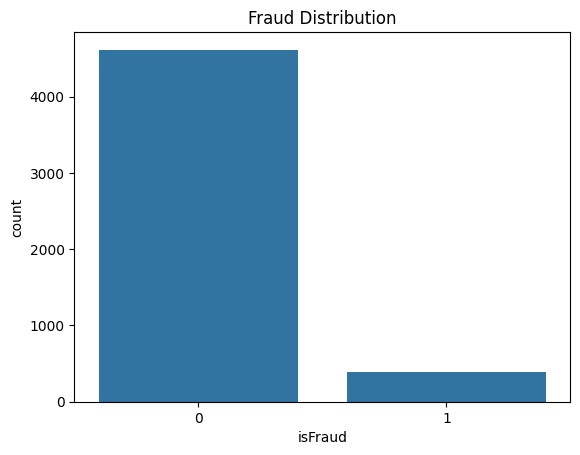

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="isFraud", data=df_clean)

plt.title("Fraud Distribution")
plt.show()

# **Slide 7:  Model Performance Comparison**

# **Step 1: Prepare Modelling Dataset**

In [ ]:
# Step 1: Prepare Modelling Dataset
# Copy cleaned dataset

df_model = df_clean.copy()

# Drop columns not used for modelling
drop_cols = [
    "TransactionID",
    "Customer_Email",
    "Card_Last4",
    "Rule_Triggered",
    "Final_Outcome",
    "Chargeback_Flag",
    "Transaction_DateTime"
]

df_model = df_model.drop(columns=drop_cols)

print(df_model.columns.tolist())

['TransactionAmt', 'card4', 'card6', 'Card_BIN', 'BIN_Risk_Level', 'Customer_Status', 'Risk_Score', 'Velocity_Attack_Flag', 'DeviceType', 'DeviceInfo', 'P_emaildomain', 'isFraud', 'Hour_of_Day', 'Day_of_Week', 'Log_TransactionAmt', 'Transactions_Per_Email', 'Unique_Cards_Per_Email', 'Transactions_Per_BIN']


# **Step 2: Define Features and Target**

In [ ]:
# Step 2: Define Features and Target

X = df_model.drop(columns=["isFraud"])

y = df_model["isFraud"]

print(X.shape)
print(y.shape)

(5000, 17)
(5000,)


# **Step 3: Train-Test Split (Stratified)**

In [ ]:
# Step 3: Train-Test Split (Stratified)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

isFraud
0    0.923
1    0.077
Name: proportion, dtype: float64
isFraud
0    0.923
1    0.077
Name: proportion, dtype: float64


# **Step 4: Encode Categorical Features**

In [ ]:
# Step 4: Encode Categorical Features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ),
        (
            "num",
            "passthrough",
            num_cols
        )
    ]
)

Categorical: ['card4', 'card6', 'BIN_Risk_Level', 'Customer_Status', 'Velocity_Attack_Flag', 'DeviceType', 'DeviceInfo', 'P_emaildomain', 'Day_of_Week']
Numeric: ['TransactionAmt', 'Card_BIN', 'Risk_Score', 'Hour_of_Day', 'Log_TransactionAmt', 'Transactions_Per_Email', 'Unique_Cards_Per_Email', 'Transactions_Per_BIN']


# **Step 5: Train Logistic Regression**

In [ ]:
# Step 5: Train Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['card4', 'card6',
                                                   'BIN_Risk_Level',
                                                   'Customer_Status',
                                                   'Velocity_Attack_Flag',
                                                   'DeviceType', 'DeviceInfo',
                                                   'P_emaildomain',
                                                   'Day_of_Week']),
                                                 ('num', 'passthrough',
                                                  ['TransactionAmt', 'Card_BIN',
                                                   'Risk_Score', 'Hour_of_Day',
                                                   'Log_TransactionAmt',
                                                   'Transactions_Per_Email',
                                                   'Unique_Cards_Per_Email',
                                                   'Transactions_Per_BIN'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

# **Step 6: Train Decision Tree**

In [ ]:
# Step 6: Train Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42,
            class_weight="balanced"
        )
    )
])

dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['card4', 'card6',
                                                   'BIN_Risk_Level',
                                                   'Customer_Status',
                                                   'Velocity_Attack_Flag',
                                                   'DeviceType', 'DeviceInfo',
                                                   'P_emaildomain',
                                                   'Day_of_Week']),
                                                 ('num', 'passthrough',
                                                  ['TransactionAmt', 'Card_BIN',
                                                   'Risk_Score', 'Hour_of_Day',
                                                   'Log_TransactionAmt',
                                                   'Transactions_Per_Email',
                                                   'Unique_Cards_Per_Email',
                                                   'Transactions_Per_BIN'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

# **Step 7: Train Random Forest**

In [ ]:
# Step 7: Train Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        )
    )
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['card4', 'card6',
                                                   'BIN_Risk_Level',
                                                   'Customer_Status',
                                                   'Velocity_Attack_Flag',
                                                   'DeviceType', 'DeviceInfo',
                                                   'P_emaildomain',
                                                   'Day_of_Week']),
                                                 ('num', 'passthrough',
                                                  ['TransactionAmt', 'Card_BIN',
                                                   'Risk_Score', 'Hour_of_Day',
                                                   'Log_TransactionAmt',
                                                   'Transactions_Per_Email',
                                                   'Unique_Cards_Per_Email',
                                                   'Transactions_Per_BIN'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

# **Step 8: Evaluate All Models**

In [ ]:
# Step 8: Evaluate All Models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
)

results_df = results_df.round(3)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.659,0.139,0.662,0.230,0.689
1,Decision Tree,0.803,0.174,0.416,0.245,0.658
2,Random Forest,0.922,0.000,0.000,0.000,0.718


# **Step 9: Champion Model**  => No, We missed XGBOOST Model

In [ ]:
# Step 9: Champion Model

print(results_df)

                 Model  Accuracy  Precision  Recall     F1  ROC_AUC
0  Logistic Regression     0.659      0.139   0.662  0.230    0.689
1        Decision Tree     0.803      0.174   0.416  0.245    0.658
2        Random Forest     0.922      0.000   0.000  0.000    0.718


# **Step 10: Confusion Matrix for Champion Model**

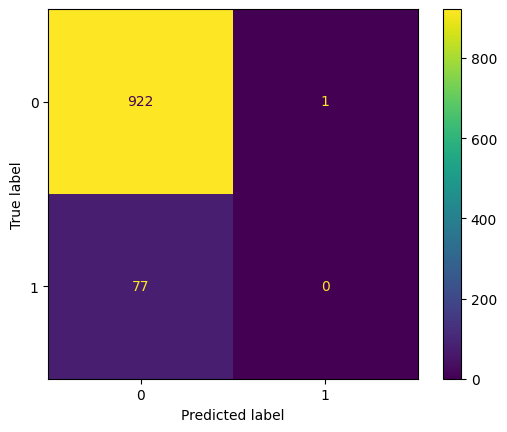

In [ ]:
# Confusion Matrix for Champion Model (Random Forest)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = rf_model   # change if another model wins

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

# **Results**

In [ ]:
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.659,0.139,0.662,0.230,0.689
1,Decision Tree,0.803,0.174,0.416,0.245,0.658
2,Random Forest,0.922,0.000,0.000,0.000,0.718


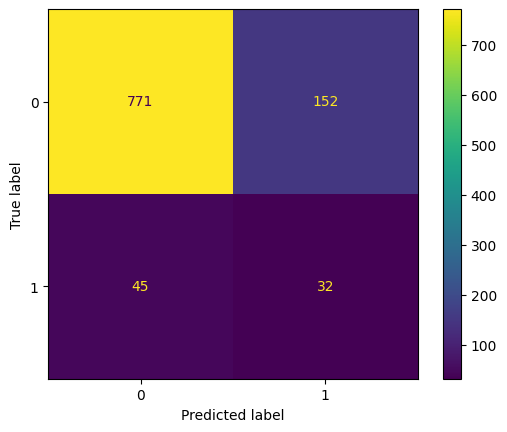

In [ ]:
# Decision Tree Confusion Matrix.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_dt = dt_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()


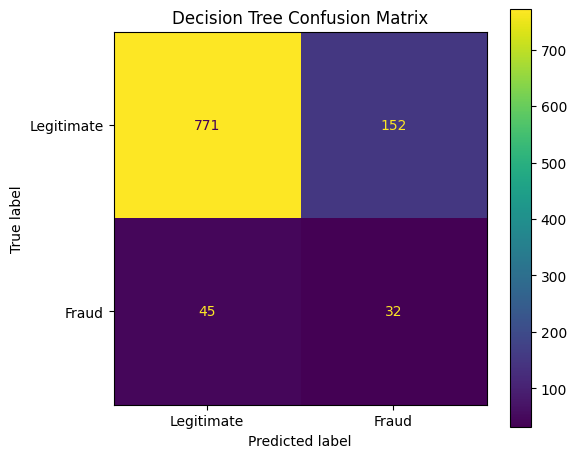

In [ ]:
#Decision Tree Confusion Matrix:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Decision Tree Predictions
y_pred_dt = dt_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Plot
fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(
    cmap="viridis",
    ax=ax,
    colorbar=True
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

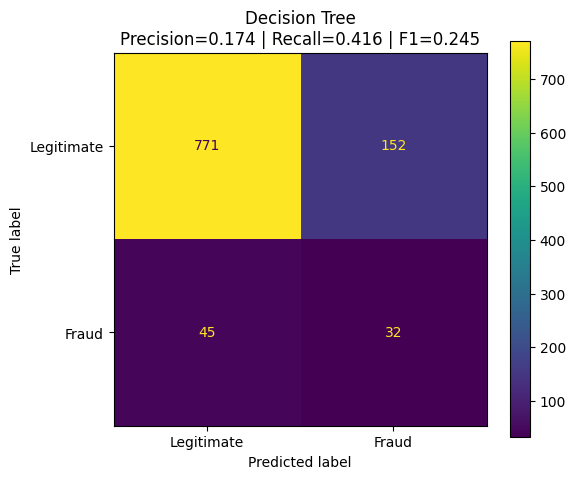

In [ ]:
# Decision Tree Confusion Matrix:

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Metrics
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(
    cmap="viridis",
    ax=ax,
    colorbar=True
)

plt.title(
    f"Decision Tree\n"
    f"Precision={precision:.3f} | Recall={recall:.3f} | F1={f1:.3f}"
)

plt.tight_layout()
plt.show()

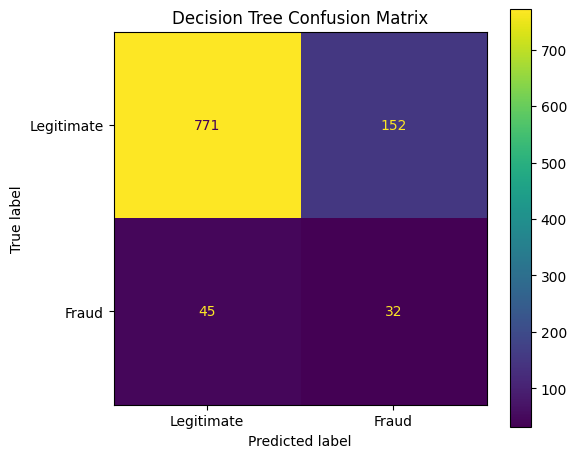

In [ ]:
# Save as PNG for PowerPoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_dt = dt_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(
    cmap="viridis",
    ax=ax
)

plt.title("Decision Tree Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "Decision_Tree_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **XGBoost : Step 1 Install XGBoost**

In [ ]:
!pip install xgboost


# **Step 2: Train XGBoost**

In [ ]:
# Step 2: Train XGBoost

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=12,
            random_state=42,
            eval_metric="logloss"
        )
    )
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['card4', 'card6',
                                                   'BIN_Risk_Level',
                                                   'Customer_Status',
                                                   'Velocity_Attack_Flag',
                                                   'DeviceType', 'DeviceInfo',
                                                   'P_emaildomain',
                                                   'Day_of_Week']),
                                                 ('num', 'passthrough',
                                                  ['TransactionAmt', 'Card_BIN',
                                                   'Risk_Score', 'Hour_of_Day',
                                                   'Log_TransactionAmt',
                                                   'Transact...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
# Transform test data
X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

print(type(X_test_transformed))
print(X_test_transformed.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(1000, 474)


# **Step 3: Evaluate All Models with MCC**

In [ ]:
# Step 3: Evaluate All Models with MCC

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

results = []

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_prob),
        matthews_corrcoef(y_test, y_pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "MCC"
    ]
)

results_df = results_df.round(3)

print(results_df)

                 Model  Accuracy  Precision  Recall     F1  ROC_AUC    MCC
0  Logistic Regression     0.659      0.139   0.662  0.230    0.689  0.178
1        Decision Tree     0.803      0.174   0.416  0.245    0.658  0.173
2        Random Forest     0.922      0.000   0.000  0.000    0.718 -0.009
3              XGBoost     0.756      0.167   0.545  0.256    0.721  0.196


# **Step 4: Rank Models by Fraud Performance**

In [ ]:
# Step 4: Rank Models by Fraud Performance

results_df.sort_values(
    by=["F1", "MCC"],
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,MCC
3,XGBoost,0.756,0.167,0.545,0.256,0.721,0.196
1,Decision Tree,0.803,0.174,0.416,0.245,0.658,0.173
0,Logistic Regression,0.659,0.139,0.662,0.230,0.689,0.178
2,Random Forest,0.922,0.000,0.000,0.000,0.718,-0.009


# **Step 5: Save Results for Slide 7**

In [ ]:
# Step 5: Save Results for Slide 7

results_df.style.background_gradient(
    cmap="YlGn"
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,MCC
0,Logistic Regression,0.659000,0.139000,0.662000,0.230000,0.689000,0.178000
1,Decision Tree,0.803000,0.174000,0.416000,0.245000,0.658000,0.173000
2,Random Forest,0.922000,0.000000,0.000000,0.000000,0.718000,-0.009000
3,XGBoost,0.756000,0.167000,0.545000,0.256000,0.721000,0.196000


# **Step 6: Generate Confusion Matrix for Champion Model**

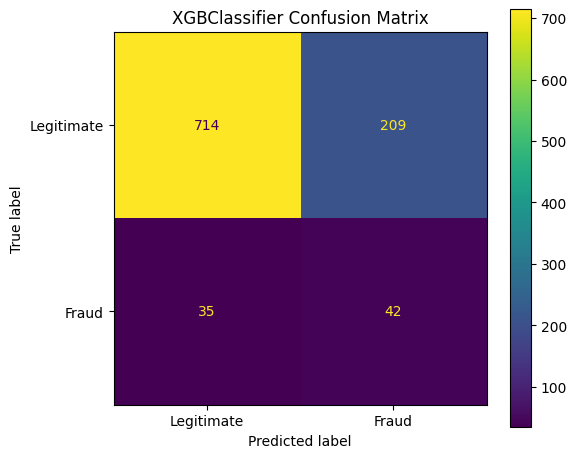

In [ ]:
# Step 6: Generate Confusion Matrix for Champion Model

best_model = xgb_model   # or dt_model depending on results

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(
    cmap="viridis",
    ax=ax
)

plt.title(
    f"{best_model.named_steps['classifier'].__class__.__name__} Confusion Matrix"
)

plt.tight_layout()

plt.show()


# **Step 1: XGBoost Feature Importance (FI)**

In [ ]:
# Step 1: XGBoost Feature Importance (FI)

xgb_classifier = xgb_model.named_steps['classifier']

feature_names = (
    xgb_model.named_steps['preprocessor']
    .get_feature_names_out()
)

feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in feature_names
]

xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_classifier.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    'importance',
    ascending=False
)

xgb_importance.head(15)

,feature,importance
420,P_emaildomain_gmail.com,0.036629
406,P_emaildomain_anonymous.com,0.034969
1,card4_american express,0.026564
423,P_emaildomain_hotmail.com,0.023050
17,DeviceType_mobile,0.021256
386,DeviceInfo_iOS Device,0.020325
7,card6_debit,0.020102
18,DeviceInfo_0,0.018663
237,DeviceInfo_SAMSUNG SM-J700T Build/NMF26X,0.018400
407,P_emaildomain_aol.com,0.018039


# **Step 2: Feature Importance Chart**

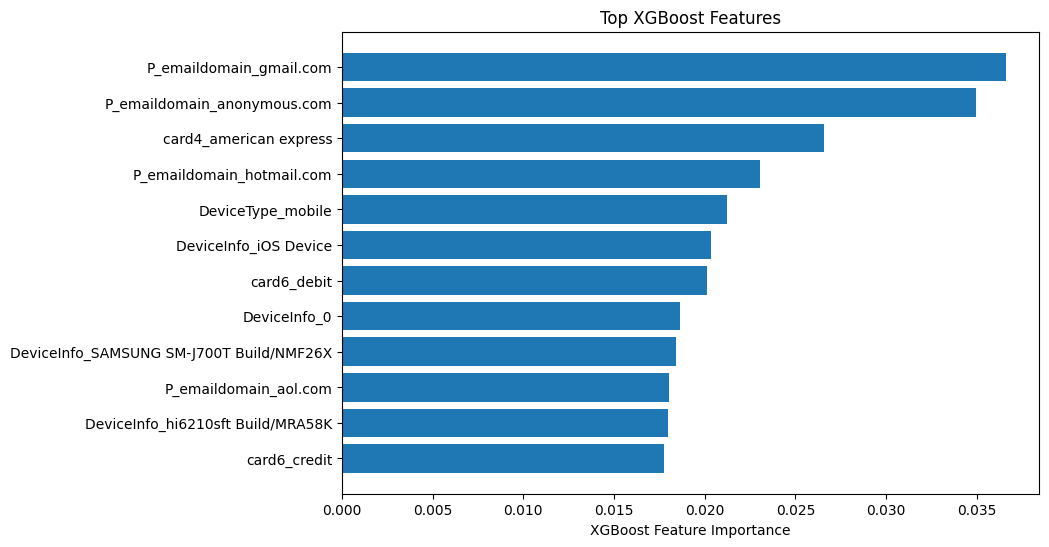

In [ ]:
# Step 2: Feature Importance Chart

import matplotlib.pyplot as plt

top_fi = (
    xgb_importance
    .head(12)
    .sort_values('importance')
)

plt.figure(figsize=(9,6))

plt.barh(
    top_fi['feature'],
    top_fi['importance']
)

plt.xlabel('XGBoost Feature Importance')
plt.title('Top XGBoost Features')

plt.show()

# **Step 3: Permutation Feature Importance (PFI)**

In [ ]:
# Step 3: Permutation Feature Importance (PFI)

from sklearn.inspection import permutation_importance

pfi_result = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

pfi_df = pd.DataFrame({
    'feature': X_test.columns,
    'mean_f1_drop': pfi_result.importances_mean,
    'std': pfi_result.importances_std
})

pfi_df = pfi_df.sort_values(
    'mean_f1_drop',
    ascending=False
)

pfi_df.head(15)

,feature,mean_f1_drop,std
10,P_emaildomain,0.051953,0.014037
9,DeviceInfo,0.047180,0.010920
0,TransactionAmt,0.030621,0.014442
2,card6,0.022356,0.007678
3,Card_BIN,0.016985,0.009786
8,DeviceType,0.009701,0.005396
11,Hour_of_Day,0.007001,0.009696
16,Transactions_Per_BIN,0.006476,0.000779
5,Customer_Status,0.006326,0.001353
12,Day_of_Week,0.006293,0.007170


# **Step 4: PFI Chart**

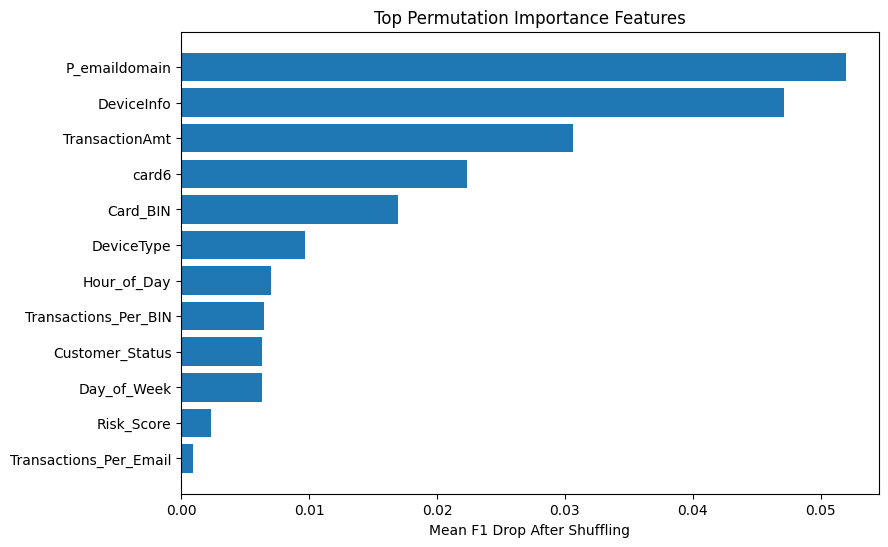

In [ ]:
# Step 4: PFI Chart

top_pfi = (
    pfi_df
    .head(12)
    .sort_values('mean_f1_drop')
)

plt.figure(figsize=(9,6))

plt.barh(
    top_pfi['feature'],
    top_pfi['mean_f1_drop']
)

plt.xlabel('Mean F1 Drop After Shuffling')
plt.title('Top Permutation Importance Features')

plt.show()

# **Step 5: Comparison Table (FI vs PFI)**

In [ ]:
# Step 5: Comparison Table (FI vs PFI)

fi_top = (
    xgb_importance[['feature', 'importance']]
    .copy()
)

pfi_top = (
    pfi_df[['feature', 'mean_f1_drop', 'std']]
    .copy()
)

comparison_df = fi_top.merge(
    pfi_top,
    on='feature',
    how='outer'
)

comparison_df = comparison_df.sort_values(
    'mean_f1_drop',
    ascending=False
)

comparison_df.head(15)

,feature,importance,mean_f1_drop,std
410,P_emaildomain,NaN,0.051953,0.014037
16,DeviceInfo,NaN,0.047180,0.010920
466,TransactionAmt,0.015666,0.030621,0.014442
479,card6,NaN,0.022356,0.007678
4,Card_BIN,0.014000,0.016985,0.009786
404,DeviceType,NaN,0.009701,0.005396
408,Hour_of_Day,0.012296,0.007001,0.009696
467,Transactions_Per_BIN,0.007683,0.006476,0.000779
5,Customer_Status,NaN,0.006326,0.001353
8,Day_of_Week,NaN,0.006293,0.007170


# **For SLide 9: ROC Curve**

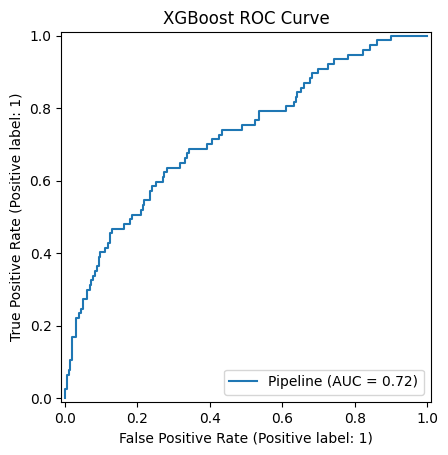

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)

plt.title("XGBoost ROC Curve")
plt.show()

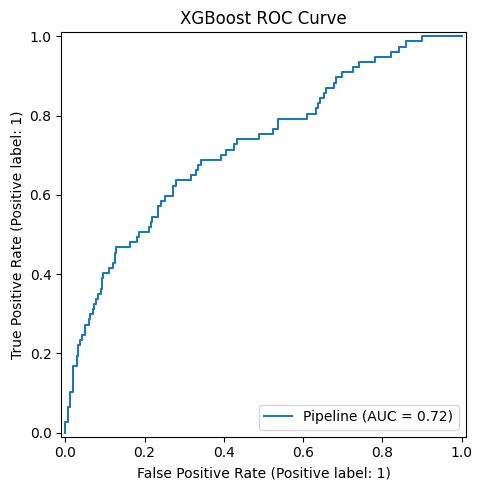

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    ax=ax
)

plt.title("XGBoost ROC Curve")

plt.tight_layout()

plt.savefig(
    "XGBoost_ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
import pandas as pd


In [ ]:
X_test_dense = X_test_transformed.toarray()

In [ ]:
xgb_classifier = xgb_model.named_steps['classifier']

feature_names = (
    xgb_model.named_steps['preprocessor']
    .get_feature_names_out()
)

feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in feature_names
]

X_test_df = pd.DataFrame(
    X_test_dense,
    columns=feature_names
)

In [ ]:
import shap

# Get trained XGBoost model
xgb_classifier = xgb_model.named_steps['classifier']

# Transform test data
X_test_transformed = xgb_model.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_test_transformed)

type(shap_values)

numpy.ndarray

# **SHAP Beewarm Plot**

In [ ]:
print(shap_values.shape)
print(len(feature_names))


(1000, 474)
474


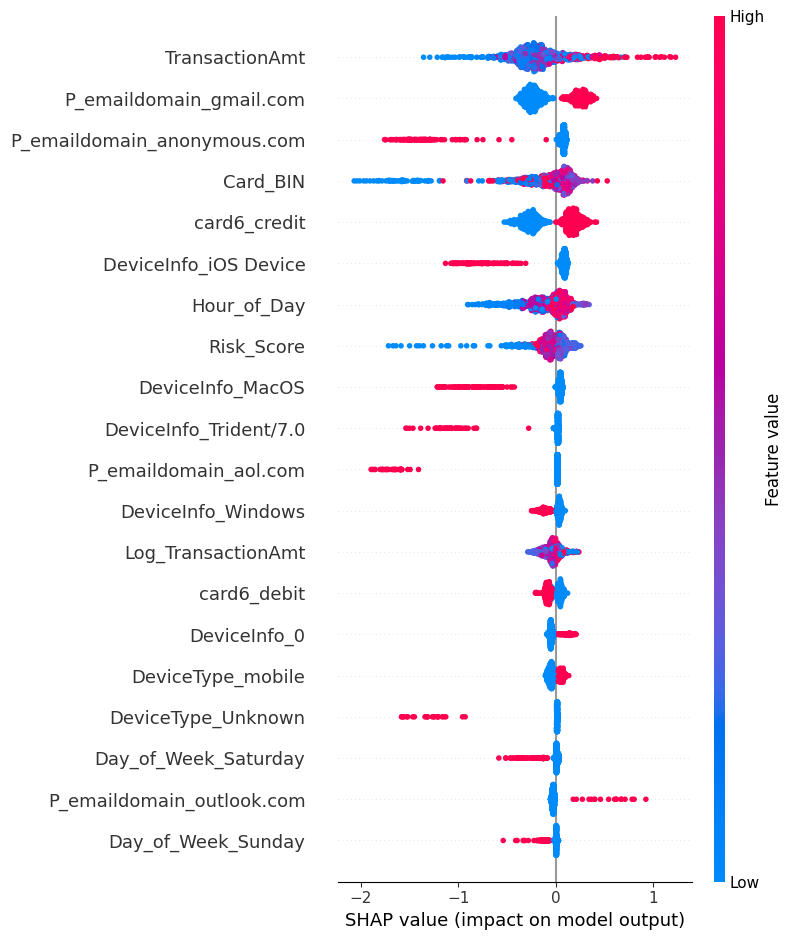

In [ ]:
# Keep original SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Convert sparse -> dense only for display
X_test_dense = X_test_transformed.toarray()

shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=feature_names,
    show=False
)

plt.show()

In [ ]:
import shap

# Explain a small test sample so the lab runs quickly in class.
X_explain = X_test.iloc[:474].copy()
y_explain = y_test.iloc[:474].copy()
pred_explain = xgb_model.predict(X_explain)

# Get the trained XGBoost model from the pipeline
xgb_classifier = xgb_model.named_steps['classifier']

# Preprocess X_explain using the pipeline's preprocessor
X_explain_transformed = xgb_model.named_steps['preprocessor'].transform(X_explain)

explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_explain_transformed)

print('Rows explained:', X_explain.shape[0])
print('SHAP values shape:', shap_values.shape)

Rows explained: 474
SHAP values shape: (474, 474)


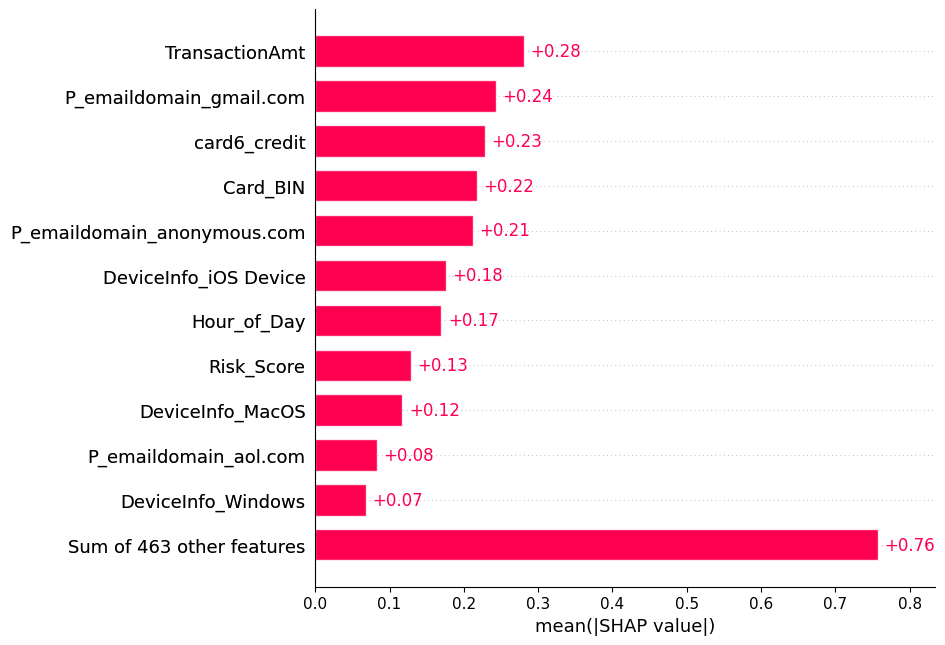

In [ ]:
import shap
import matplotlib.pyplot as plt

# Ensure X_explain_transformed is a dense array for the Explanation object's data argument
X_explain_transformed_dense = X_explain_transformed.toarray()

# Create a shap.Explanation object
explanation_obj = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_explain_transformed_dense,
    feature_names=feature_names
)

# Now pass the Explanation object to shap.plots.bar
shap.plots.bar(explanation_obj, max_display=12)
plt.show()

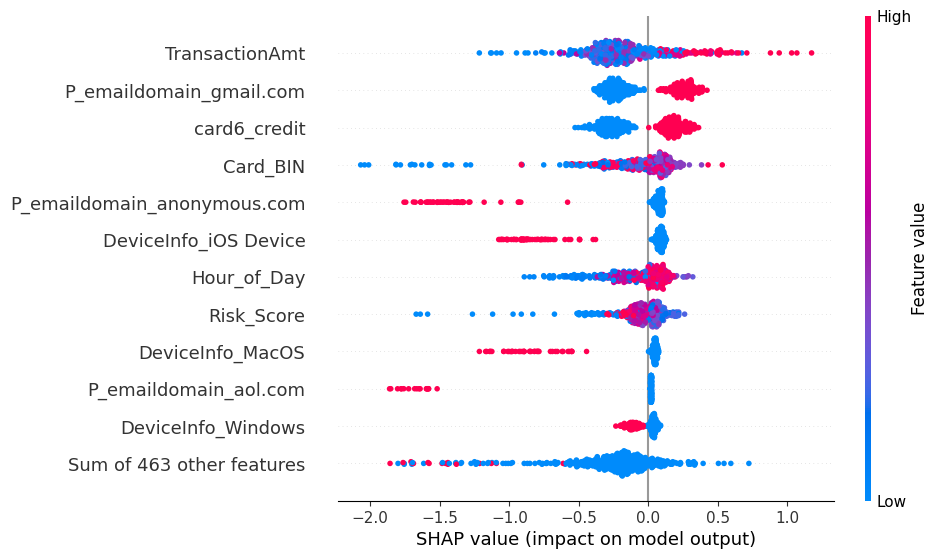

In [ ]:
import shap
import matplotlib.pyplot as plt

# Ensure X_explain_transformed is a dense array for the Explanation object's data argument
X_explain_transformed_dense = X_explain_transformed.toarray()

# Create a shap.Explanation object from the previously computed shap_values
explanation_obj = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_explain_transformed_dense,
    feature_names=feature_names
)

# Now pass the Explanation object to shap.plots.beeswarm
shap.plots.beeswarm(explanation_obj, max_display=12)
plt.show()

In [ ]:
print(shap_values)

[[ 0.00000000e+00  3.23679065e-03  0.00000000e+00 ... -5.06475056e-03
   3.11126525e-04  4.42109304e-03]
 [ 0.00000000e+00  3.74709349e-03  0.00000000e+00 ... -4.78693633e-04
   1.08253982e-04 -6.85938867e-04]
 [ 0.00000000e+00  3.30323447e-03  0.00000000e+00 ... -6.98520977e-04
   1.08253982e-04  4.74269036e-05]
 ...
 [ 0.00000000e+00  3.70278233e-03  0.00000000e+00 ... -4.88546502e-04
   3.11126525e-04 -6.24952978e-03]
 [ 0.00000000e+00  3.99655383e-03  0.00000000e+00 ... -5.06475056e-03
   3.11126525e-04 -7.79192057e-03]
 [ 0.00000000e+00  4.08634637e-03  0.00000000e+00 ... -7.54271052e-04
   3.11126525e-04 -1.29058445e-02]]


Top SHAP feature: TransactionAmt


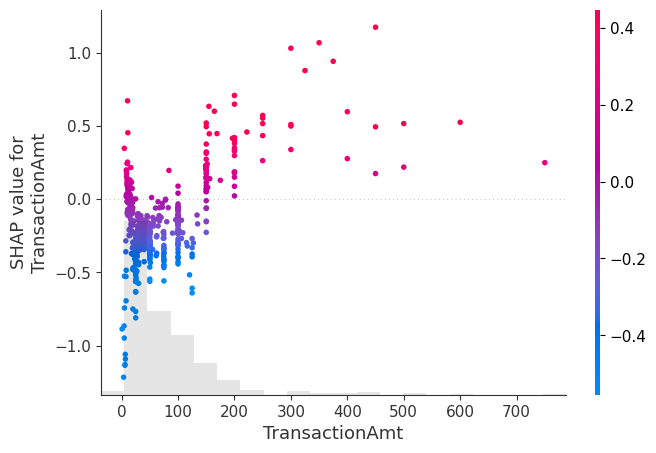

In [ ]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_index = mean_abs_shap.argmax()
top_feature = feature_names[top_feature_index]

print('Top SHAP feature:', top_feature)

# Correctly pass the Explanation object for the scatter plot
# and specify the feature for the x-axis. The color argument usually takes
# the SHAP values for the same feature to show interaction or distribution.
shap.plots.scatter(explanation_obj[:, top_feature_index], color=explanation_obj.values[:, top_feature_index])

# **Chapter 10. Explain one prediction using a waterfall plot**

In [ ]:
row_id = 0

target_names = ['Legitimate', 'Fraud'] # Define target names for clarity

print('Actual class:', y_explain.iloc[row_id])
print('Predicted class:', pred_explain[row_id])
print('Target names:', target_names)

X_explain.iloc[[row_id]]

Actual class: 0
Predicted class: 0
Target names: ['Legitimate', 'Fraud']


,TransactionAmt,card4,card6,Card_BIN,BIN_Risk_Level,Customer_Status,Risk_Score,Velocity_Attack_Flag,DeviceType,DeviceInfo,P_emaildomain,Hour_of_Day,Day_of_Week,Log_TransactionAmt,Transactions_Per_Email,Unique_Cards_Per_Email,Transactions_Per_BIN
4817,120.417,mastercard,debit,557889,Low,New User,44,No,desktop,Windows,Unknown,21,Friday,4.799231,1,1,1


In [ ]:
import shap
import matplotlib.pyplot as plt

def plot_waterfall_for_row(row_id):
    """Generates a SHAP waterfall plot for a given row_id."""

    # Ensure row_id is within bounds
    if row_id < 0 or row_id >= X_explain_transformed_dense.shape[0]:
        print(f"Error: row_id {row_id} is out of bounds. Must be between 0 and {X_explain_transformed_dense.shape[0] - 1}.")
        return

    # Create a shap.Explanation object for the specific row
    single_shap = shap.Explanation(
        values=shap_values[row_id],
        base_values=explainer.expected_value,
        data=X_explain_transformed_dense[row_id],
        feature_names=feature_names
    )

    # Generate and display the waterfall plot
    shap.plots.waterfall(
        single_shap,
        max_display=10,
        show=False
    )

    plt.title(
        f"Waterfall Plot: Explanation for Row ID {row_id}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

Now, let's test the function with `row_id = 0` (the same one as before) and `row_id = 5`.

Generating waterfall plot for row_id = 40:


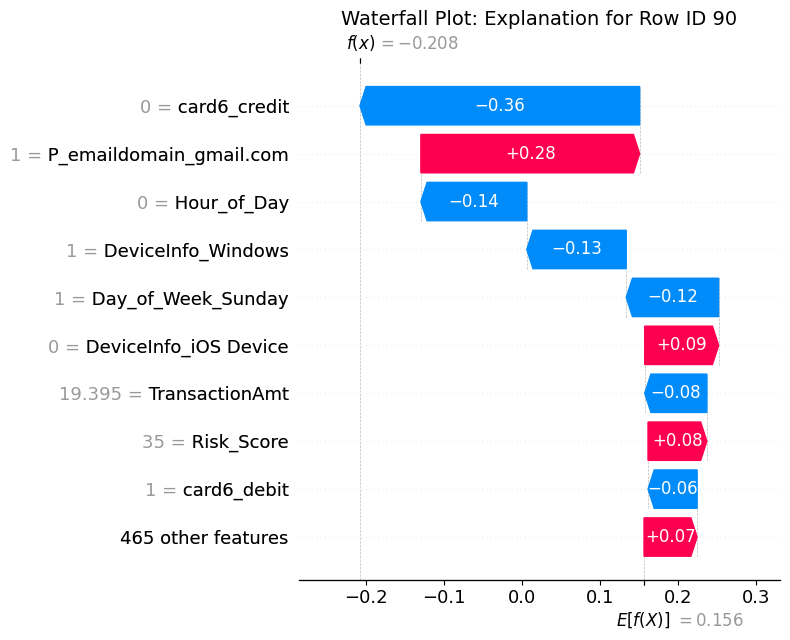

In [ ]:
# Demonstrate the function for row_id = 0
print("Generating waterfall plot for row_id = 40:")
plot_waterfall_for_row(90)

Generating waterfall plot for row_id = 5:


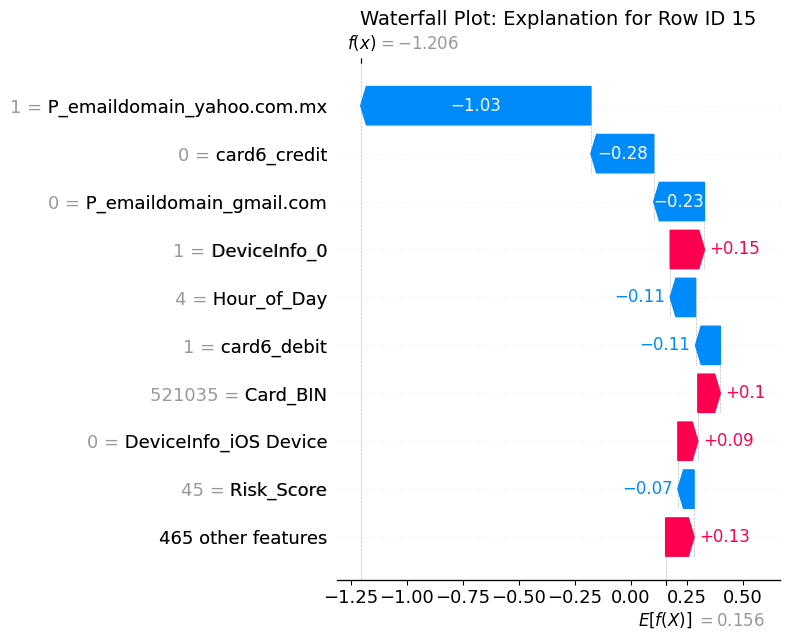

In [ ]:
# Demonstrate the function for row_id = 5
print("Generating waterfall plot for row_id = 5:")
plot_waterfall_for_row(15)

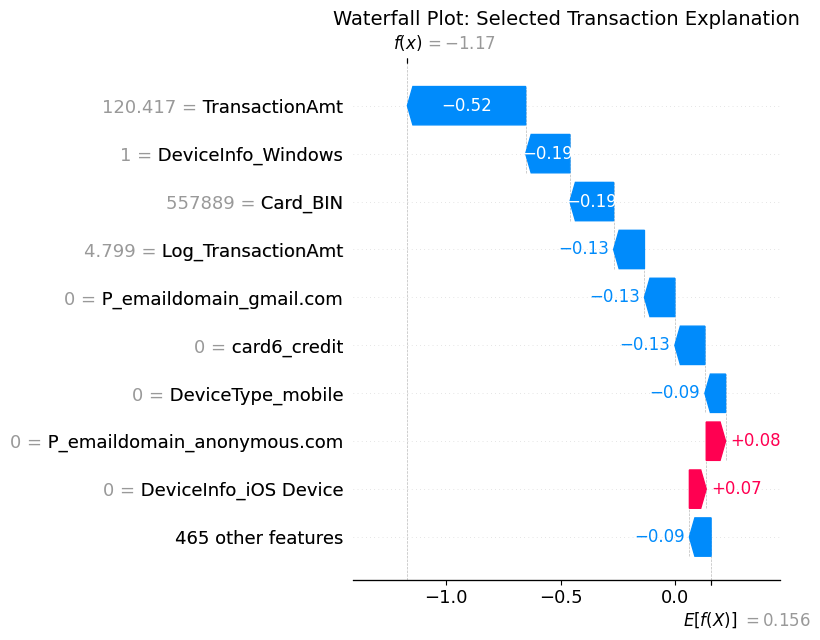

In [ ]:
# Create SHAP Waterfall Plot for the highest risk transaction

import shap
import matplotlib.pyplot as plt

# Using 'row_id' to select the specific transaction for the waterfall plot.
# 'idx' is defined later for the highest risk transaction across the whole test set,
# but 'row_id' is appropriate here given the previous cell's context.

single_shap = shap.Explanation(
    values=shap_values[row_id],
    base_values=explainer.expected_value,
    data=X_explain_transformed_dense[row_id],
    feature_names=feature_names
)

shap.plots.waterfall(
    single_shap,
    max_display=10,
    show=False
)

plt.title(
    "Waterfall Plot: Selected Transaction Explanation",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
# Create a proper comparison dataframe with ranking

comparison_df["FI_Rank"] = (
    comparison_df["importance"]
    .rank(ascending=False, method="dense")
)

comparison_df["PFI_Rank"] = (
    comparison_df["mean_f1_drop"]
    .rank(ascending=False, method="dense")
)

comparison_df.sort_values(
    "PFI_Rank"
).head(15)

,feature,importance,mean_f1_drop,std,FI_Rank,PFI_Rank
410,P_emaildomain,NaN,0.051953,0.014037,NaN,1.0
16,DeviceInfo,NaN,0.047180,0.010920,NaN,2.0
466,TransactionAmt,0.015666,0.030621,0.014442,16.0,3.0
479,card6,NaN,0.022356,0.007678,NaN,4.0
4,Card_BIN,0.014000,0.016985,0.009786,21.0,5.0
404,DeviceType,NaN,0.009701,0.005396,NaN,6.0
408,Hour_of_Day,0.012296,0.007001,0.009696,33.0,7.0
467,Transactions_Per_BIN,0.007683,0.006476,0.000779,65.0,8.0
5,Customer_Status,NaN,0.006326,0.001353,NaN,9.0
8,Day_of_Week,NaN,0.006293,0.007170,NaN,10.0


# **Slide 11: Step 1: Generate SHAP Dependency Plot for TransactionAmt**

<Figure size 640x480 with 0 Axes>

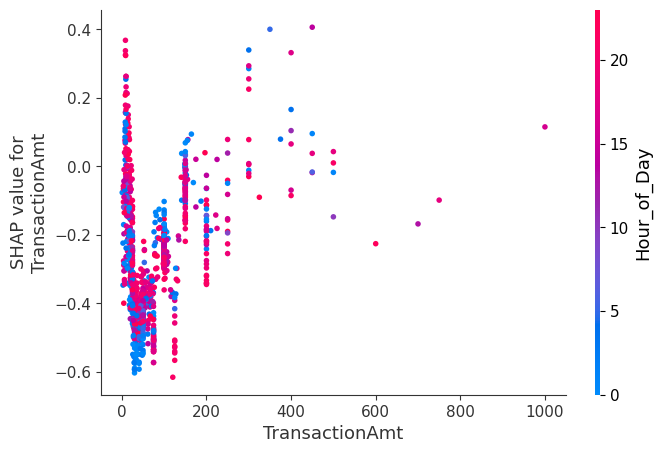

<Figure size 640x480 with 0 Axes>

In [ ]:
# Step 1: Generate SHAP Dependency Plot for TransactionAmt

import shap
import matplotlib.pyplot as plt

# Transform test data
X_test_transformed = (
    xgb_model.named_steps['preprocessor']
    .transform(X_test)
    .toarray() # Convert sparse matrix to dense array
)

# Get trained XGBoost model
xgb_classifier = xgb_model.named_steps['classifier']

explainer = shap.TreeExplainer(xgb_classifier)

shap_values = explainer.shap_values(X_test_transformed)

plt.figure()

shap.dependence_plot(
    "TransactionAmt",
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="auto"
)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'SHAP Dependency Plot: Transaction Amount vs Fraud Risk')

<Figure size 800x600 with 0 Axes>

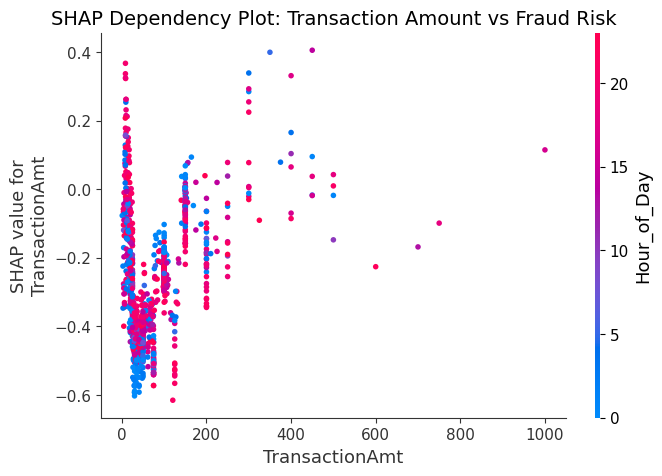

In [ ]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(8,6))

shap.dependence_plot(
    "TransactionAmt",
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependency Plot: Transaction Amount vs Fraud Risk",
    fontsize=14
)



# **Slide 12 (Dependency Plot – Email Domain)**

**Option 1: Gmail Domain**

<Figure size 800x600 with 0 Axes>

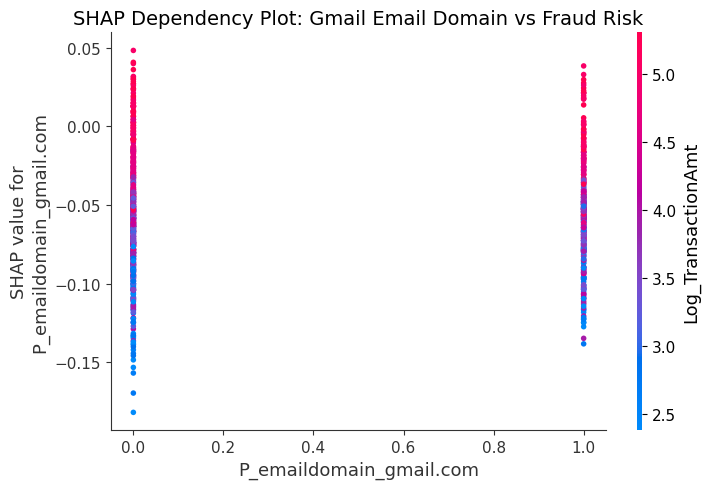

In [ ]:
# Slide 12 (Dependency Plot – Email Domain)
# Option 1: Gmail Domain

import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

shap.dependence_plot(
    "P_emaildomain_gmail.com",
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependency Plot: Gmail Email Domain vs Fraud Risk",
    fontsize=14
)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

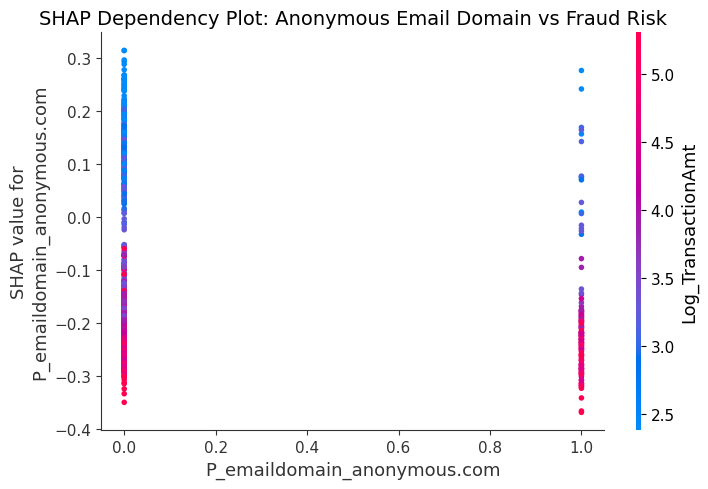

In [ ]:
# Slide 12 (Dependency Plot – Email Domain)
# Option 2: Anonymous Email Domain (Recommended)

import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

shap.dependence_plot(
    "P_emaildomain_anonymous.com",
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependency Plot: Anonymous Email Domain vs Fraud Risk",
    fontsize=14
)

plt.tight_layout()
plt.show()

Great. ✅ Between the two, I would use:

"Anonymous Email Domain vs Fraud Risk"

(not Gmail)

because:

It is more fraud-related.
The SHAP values are much larger.
The pattern is easier to explain.
It supports your Fraud Prevention Specialist story better.

The Gmail plot shows only small SHAP movements:

In [ ]:
# Slide 12 (Dependency Plot – Email Domain)
# Option 3: Check Available Email Features First

email_features = [
    f for f in feature_names
    if "P_emaildomain" in f
]

print(email_features)

['P_emaildomain_Unknown', 'P_emaildomain_anonymous.com', 'P_emaildomain_aol.com', 'P_emaildomain_att.net', 'P_emaildomain_bellsouth.net', 'P_emaildomain_cableone.net', 'P_emaildomain_cfl.rr.com', 'P_emaildomain_charter.net', 'P_emaildomain_comcast.net', 'P_emaildomain_cox.net', 'P_emaildomain_earthlink.net', 'P_emaildomain_embarqmail.com', 'P_emaildomain_frontier.com', 'P_emaildomain_frontiernet.net', 'P_emaildomain_gmail', 'P_emaildomain_gmail.com', 'P_emaildomain_gmx.de', 'P_emaildomain_hotmail.co.uk', 'P_emaildomain_hotmail.com', 'P_emaildomain_hotmail.de', 'P_emaildomain_hotmail.es', 'P_emaildomain_hotmail.fr', 'P_emaildomain_icloud.com', 'P_emaildomain_juno.com', 'P_emaildomain_live.com', 'P_emaildomain_live.com.mx', 'P_emaildomain_live.fr', 'P_emaildomain_mac.com', 'P_emaildomain_mail.com', 'P_emaildomain_me.com', 'P_emaildomain_msn.com', 'P_emaildomain_netzero.net', 'P_emaildomain_optonline.net', 'P_emaildomain_outlook.com', 'P_emaildomain_outlook.es', 'P_emaildomain_prodigy.net

<Figure size 800x600 with 0 Axes>

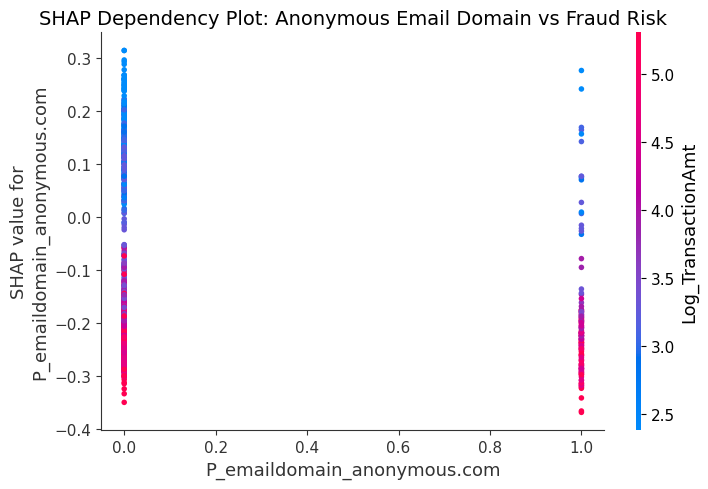

In [ ]:
# Save for PowerPoint

import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

shap.dependence_plot(
    "P_emaildomain_anonymous.com",
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependency Plot: Anonymous Email Domain vs Fraud Risk",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "SHAP_Dependency_EmailDomain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **To check the DeviceInfo**

In [ ]:
# Device info Dependency plot

device_features = [
    f for f in feature_names
    if "DeviceInfo" in f
]

print(device_features)

['DeviceInfo_0', 'DeviceInfo_4047G Build/NRD90M', 'DeviceInfo_5010G Build/MRA58K', 'DeviceInfo_5011A Build/NRD90M', 'DeviceInfo_5012G Build/MRA58K', 'DeviceInfo_5025G Build/LMY47I', 'DeviceInfo_5049W Build/NRD90M', 'DeviceInfo_5054N', 'DeviceInfo_5054S Build/LMY47V', 'DeviceInfo_5056A Build/MMB29M', 'DeviceInfo_7048A Build/LRX22G', 'DeviceInfo_8050G Build/LMY47I', 'DeviceInfo_ALCATEL', 'DeviceInfo_ALCATEL ONE TOUCH 7047A Build/JDQ39', 'DeviceInfo_ALE-L21 Build/HuaweiALE-L21', 'DeviceInfo_ALE-L23 Build/HuaweiALE-L23', 'DeviceInfo_ALP-L09 Build/HUAWEIALP-L09S', 'DeviceInfo_ASUS_X015D Build/NRD90M', 'DeviceInfo_Alcatel_5044R Build/NRD90M', 'DeviceInfo_Alcatel_5098O Build/MMB29M', 'DeviceInfo_Android 5.1', 'DeviceInfo_Android 6.0', 'DeviceInfo_B3-A20', 'DeviceInfo_BAC-L03 Build/HUAWEIBAC-L03', 'DeviceInfo_BLADE V8 SE Build/NRD90M', 'DeviceInfo_BLL-L23 Build/HUAWEIBLL-L23', 'DeviceInfo_BNTV400', 'DeviceInfo_BOIE9', 'DeviceInfo_BV6000', 'DeviceInfo_Blade L3 Build/KOT49H', 'DeviceInfo_Blade L

# **Option 1: DeviceInfo_iOS Device**

<Figure size 800x600 with 0 Axes>

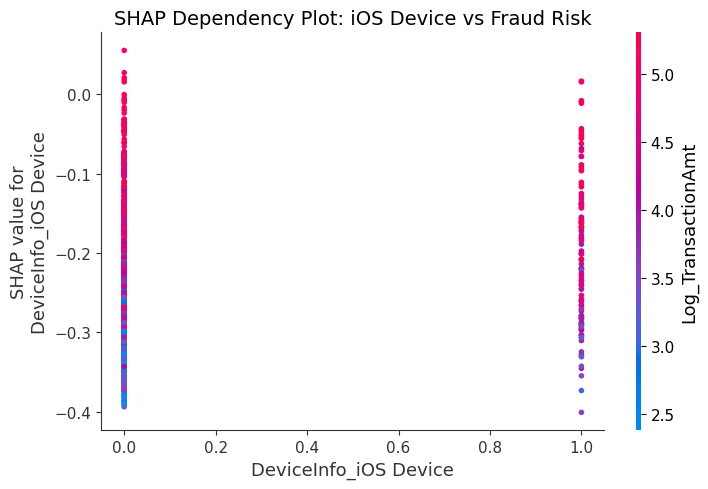

In [ ]:
# Option 1: DeviceInfo_iOS Device

import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

shap.dependence_plot(
    "DeviceInfo_iOS Device",
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependency Plot: iOS Device vs Fraud Risk",
    fontsize=14
)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

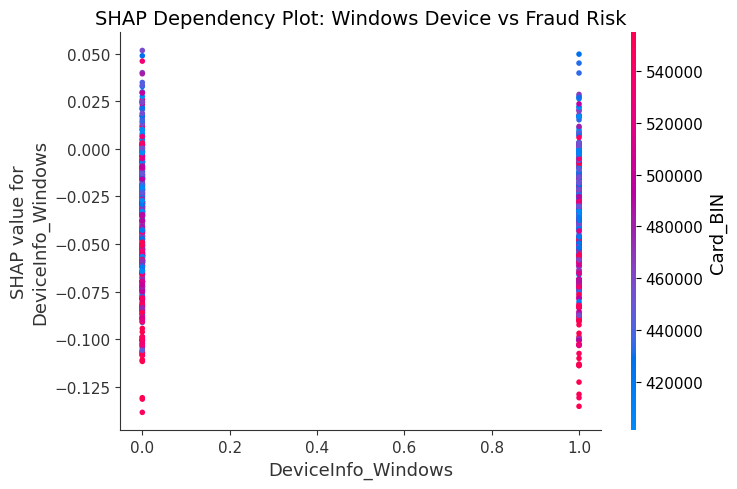

In [ ]:
# Option 2: DeviceInfo_Windows

import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

shap.dependence_plot(
    "DeviceInfo_Windows",
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependency Plot: Windows Device vs Fraud Risk",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
# Option 3: Automatically Plot Top Device Features

device_fi = xgb_importance[
    xgb_importance["feature"].str.contains("DeviceInfo", na=False)
]

print(
    device_fi.sort_values(
        "importance",
        ascending=False
    ).head(10)
)


                                      feature  importance
386                     DeviceInfo_iOS Device    0.020325
18                               DeviceInfo_0    0.018663
237  DeviceInfo_SAMSUNG SM-J700T Build/NMF26X    0.018400
384         DeviceInfo_hi6210sft Build/MRA58K    0.017950
154                          DeviceInfo_MacOS    0.017689
352                    DeviceInfo_Trident/7.0    0.017021
27              DeviceInfo_5056A Build/MMB29M    0.015605
258          DeviceInfo_SM-A300H Build/LRX22G    0.014153
360                        DeviceInfo_Windows    0.013118
53     DeviceInfo_CHC-U03 Build/HuaweiCHC-U03    0.012992


# **Slide 13: LOCAL INSIGHTS: WATERFALL PLOT**

In [ ]:
# LOCAL INSIGHTS: WATERFALL PLOT

import numpy as np

# Predicted fraud probability
y_prob = xgb_model.predict_proba(X_test)[:,1]

# Highest risk transaction
idx = np.argmax(y_prob)

print("Index:", idx)
print("Fraud Probability:", y_prob[idx])

Index: 816
Fraud Probability: 0.8937707


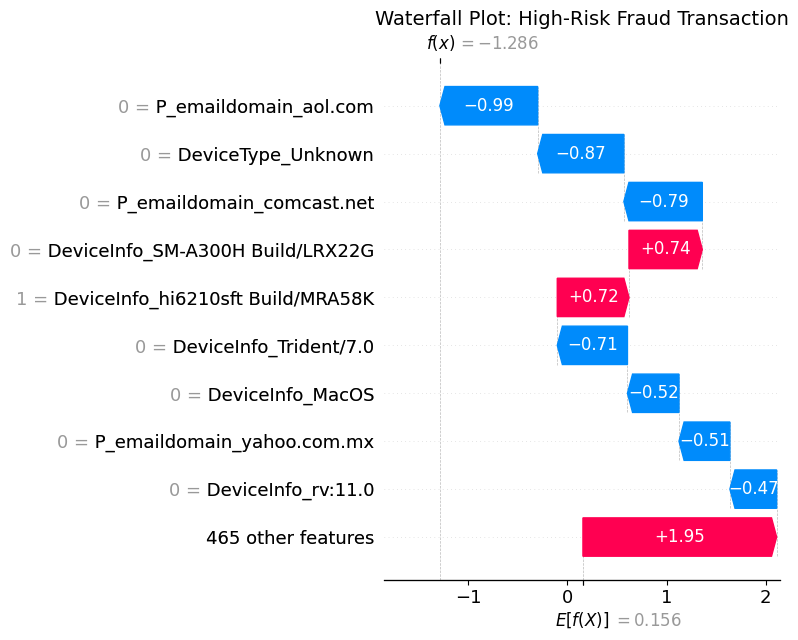

In [ ]:
# Step 2: Create SHAP Waterfall Plot

import shap
import matplotlib.pyplot as plt

single_shap = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test_transformed[idx],
    feature_names=feature_names
)

shap.plots.waterfall(
    single_shap,
    max_display=10,
    show=False
)

plt.title(
    "Waterfall Plot: High-Risk Fraud Transaction",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
print(y_prob[idx])
print(y_test.iloc[idx])

0.8937707
1


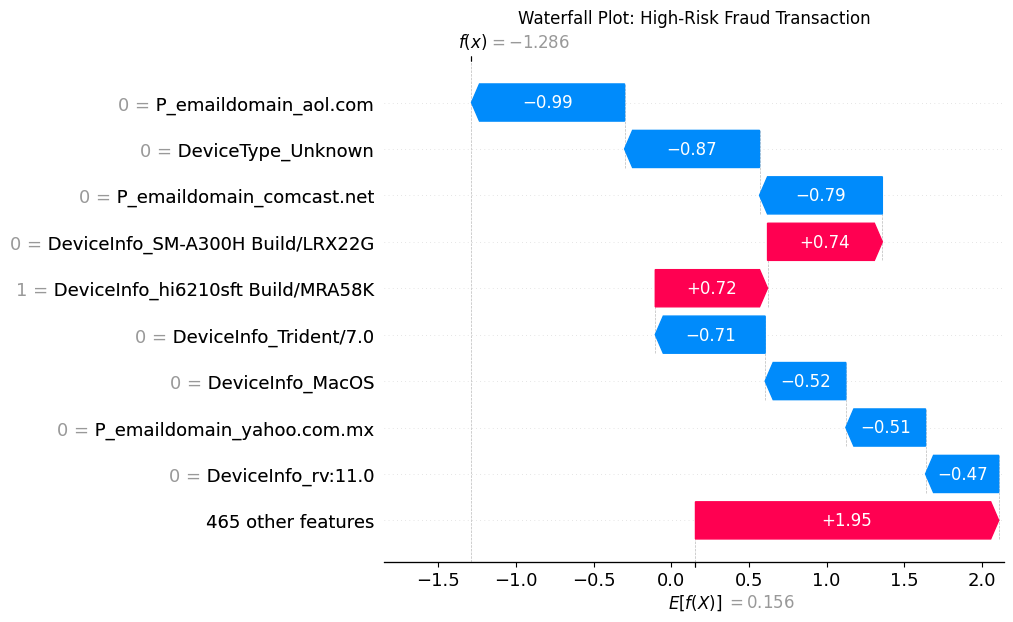

In [ ]:
# Step 3: Save for Powerpoint.

import matplotlib.pyplot as plt
import shap

single_shap = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test_transformed[idx],
    feature_names=feature_names
)

shap.plots.waterfall(
    single_shap,
    max_display=10,
    show=False
)

plt.title("Waterfall Plot: High-Risk Fraud Transaction")

plt.savefig(
    "Fraud_Waterfall_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import numpy as np

# Calculate f(x) for each instance in the test set
f_x_values = explainer.expected_value + shap_values.sum(axis=1)

# Find the index of the transaction with the highest f(x)
highest_f_x_row_index = np.argmax(f_x_values)

print(f"The index of the transaction with the highest f(x) is: {highest_f_x_row_index}")
print(f"The highest f(x) value is: {f_x_values[highest_f_x_row_index]:.4f}")

# **Slide 14: DEPLOYMENT JUSTIFICATION & PRACTICALITY**

# **Slide 15: Rule Backtesting**

Rule V1 (Current)
No additional controls

Rule V2 (Proposed)
IF P_emaildomain = anonymous.com
AND TransactionAmt > threshold
THEN Trigger Review

Then compare:

Fraud Detection Rate
False Positive Rate
Precision


In [ ]:
import pandas as pd

backtest_df = df_clean.copy()

# Proposed Rule
backtest_df["Rule_Flag"] = (
    (backtest_df["P_emaildomain"] == "anonymous.com")
    &
    (backtest_df["TransactionAmt"] > 300)
)

# Confusion Table
summary = pd.crosstab(
    backtest_df["Rule_Flag"],
    backtest_df["isFraud"],
    margins=True
)

print(summary)

isFraud       0    1   All
Rule_Flag                 
False      4584  385  4969
True         31    0    31
All        4615  385  5000


In [ ]:
# Fraud Detection Rate

fraud_total = backtest_df["isFraud"].sum()

fraud_caught = backtest_df[
    (backtest_df["Rule_Flag"] == True)
    &
    (backtest_df["isFraud"] == 1)
].shape[0]

print(
    "Fraud Detection Rate:",
    round(fraud_caught / fraud_total * 100,2),
    "%"
)

Fraud Detection Rate: 0.0 %


In [ ]:
# Precision

flagged_txns = backtest_df[
    backtest_df["Rule_Flag"] == True
]

precision = (
    flagged_txns["isFraud"]
    .mean()
)

print(
    "Rule Precision:",
    round(precision*100,2),
    "%"
)


Rule Precision: 0.0 %


In [ ]:
# False Positive Rate

false_positives = backtest_df[
    (backtest_df["Rule_Flag"] == True)
    &
    (backtest_df["isFraud"] == 0)
].shape[0]

print(
    "False Positives:",
    false_positives
)

False Positives: 31
